In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline 


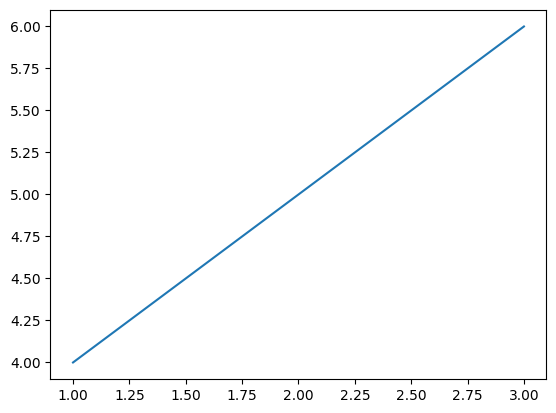

In [2]:
plt.plot([1,2,3],[4,5,6])


In [3]:
def quad(x):
    return 3*x**2

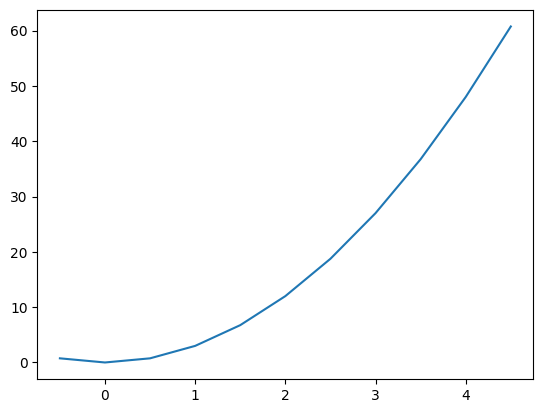

In [4]:
x= np.arange(-0.5,5,0.5) 
y=quad(x)
plt.plot(x,y)

In [5]:
def f(x):
    return 2*x**2-6*x+2

In [6]:
f(2)

-2

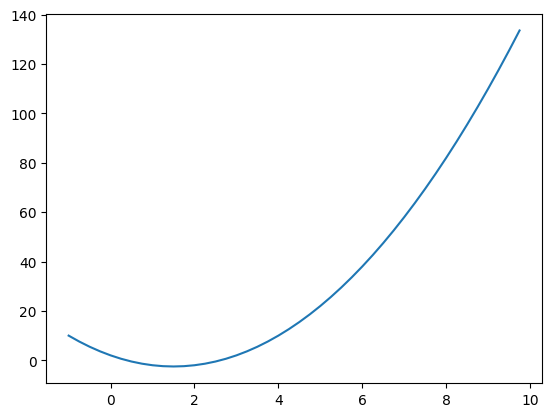

In [7]:
x=np.arange(-1,10,0.25)
y=f(x)
plt.plot(x,y)

In [ ]:
h=0.0000000000000000001
x=3.0
(f(x+h)-f(x))/h

0.0

: 

In [179]:
f=5

class Value:
    def __init__(self,data,children=(),_opr='',label=''):
       self.data=data
       self.previousvars=set(children)
       self._opr= _opr
       self.label=label
    def __repr__(self):
       return f"Value(data={self.data})"
    def __add__(self,other):
       sum= Value(self.data+ other.data,(self,other),'+')
       return sum
    def __mul__(self,other):
       mul= Value(self.data * other.data,(self,other),'*')
       return mul
    
a = Value(2.0,label='a')
b = Value(3.0,label='b')
e= Value(4.0,label='e')
c=(b+e)
c.label='c'
# print(a)


# print(b)
c

type(c)
type(f)

int

In [180]:
c.data

7.0

In [181]:
c.previousvars


{Value(data=3.0), Value(data=4.0)}

In [182]:
c._opr

'+'

In [183]:
!pip install graphviz


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from graphviz import Digraph

class Value:
    """
    Represents one node in a computational graph.

    Attributes:
        data (float): Numeric value stored in node.
        previousvars (set): Parent nodes used to create this node.
        _opr (str): Operation used to create node (+, *).
        label (str): Optional node name.
    """

    def __init__(self, data, children=(), _opr='', label=''):
        self.data = data
        self.previousvars = set(children)
        self._opr = _opr
        self.label = label
        self.grad=0.0
        self.backward= lambda : None

    def __repr__(self):
        """
        Returns readable string representation.
        """
        return f"Value(data={self.data})"
    

    def __add__(self, other):
        """
        Adds two Value objects and creates a new graph node.
        """
        sum=Value(self.data + other.data, (self, other), '+')
        def backward():
          self.backward=1.0*sum.grad
          other.backward=1.0*sum.grad
        sum.backward=backward
        return sum

    def __mul__(self, other):
        """
        Multiplies two Value objects and creates a new graph node.
        """
        prd=Value(self.data * other.data, (self, other), '*')
        def backward():
          self.backward= other.data*prd.grad
          other.backward= self.data*prd.grad
        prd.backward=backward
        return prd
    
    def tanh(self):
        x=self.data


def trace(root):
    """
    Traverses graph from root node.

    Args:
        root (Value): Final output node.

    Returns:
        tuple:
            nodes -> all Value nodes
            edges -> parent-child relationships
    """
    nodes, edges = set(), set()

    def build(v):
        """
        Recursive DFS traversal.
        """
        if v not in nodes:
            nodes.add(v)

            for child in v.previousvars:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    """
    Draws computational graph using Graphviz.

    Args:
        root (Value): Final output node.

    Returns:
        Digraph: Renderable graph object.
    """
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n)

        # create value node
        dot.node(
            name=uid,
            label="{ %s | data %.4f | grad %.4f}" % (n.label, n.data,n.grad),
            shape="record"
        )

        # create operation node
        if n._opr:
            dot.node(name=uid + n._opr, label=n._opr)
            dot.edge(uid + n._opr, uid)

    # connect parents to operation nodes
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._opr)

    return dot


In [19]:
from graphviz import Digraph



def draw_dot(root):
    """
    Draws computational graph using Graphviz.

    Args:
        root (Value): Final output node.

    Returns:
        Digraph: Renderable graph object.
    """
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))

        # create value node
        dot.node(
            name=uid,
            label="{ %s | data %.4f | grad %.4f}" % (n.label, n.data,n.grad),
            shape="record"
        )

        # create operation node
        if n._opr:
            dot.node(name=uid + n._opr, label=n._opr)
            dot.edge(uid + n._opr, uid)

    # connect parents to operation nodes
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._opr)

    return dot


# ---------- Example ----------
a = Value(2.0, label='a')
b = Value(3.0, label='b')
e = Value(4.0, label='e')

c = a * (b + e)
c.label = 'c'

l=c
l.label='l'


draw_dot(c)

TypeError: Value.__init__() got an unexpected keyword argument 'label'

In [10]:
l.grad=1

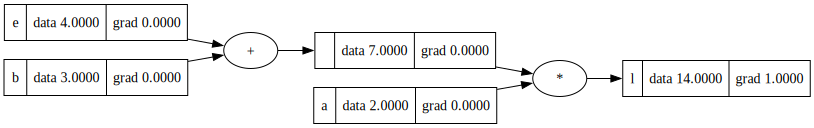

In [11]:

draw_dot(c)

In [ ]:
from graphviz import Digraph
class Value:
    """ stores a single scalar value and its gradient """

    def __init__(self, data, _children=(), _op='',label=''):
        self.data = data
        self.grad = 0
        # internal variables used for autograd graph construction
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op # the op that produced this node, for graphviz / debugging / etc
        self.label=label

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0* out.grad
            other.grad +=  1.0* out.grad
        out._backward = _backward

        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
        out._backward = _backward

        return out

    def relu(self):
        out = Value(0 if self.data < 0 else self.data, (self,), 'ReLU')

        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward

        return out

    def backward(self):

        # topological order all of the children in the graph
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        # go one variable at a time and apply the chain rule to get its gradient
        self.grad = 1
        for v in reversed(topo):
            v._backward()

    def __neg__(self): # -self
        return self * -1

    def __radd__(self, other): # other + self
        return self + other

    def __sub__(self, other): # self - other
        return self + (-other)

    def __rsub__(self, other): # other - self
        return other + (-self)

    def __rmul__(self, other): # other * self
        return self * other

    def __truediv__(self, other): # self / other
        return self * other**-1

    def __rtruediv__(self, other): # other / self
        return other * self**-1

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"
    

    def draw_dot(root):
    
        dot = Digraph(format='jpeg', graph_attr={'rankdir': 'LR'})

        nodes, edges = trace(root)

        for n in nodes:
            uid = str(id(n))

            # create value node
            dot.node(
                name=uid,
                label="{ %s | data %.4f | grad %.4f}" % (n.label, n.data,n.grad),
                shape="record"
            )

            # create operation node
            if n._opr:
                dot.node(name=uid + n._opr, label=n._opr)
                dot.edge(uid + n._opr, uid)

        # connect parents to operation nodes
        for n1, n2 in edges:
            dot.edge(str(id(n1)), str(id(n2)) + n2._opr)

        return dot

In [45]:
import random
# from micrograd.engine import Value

class Module:

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0

    def parameters(self):
        return []

class Neuron(Module):

    def __init__(self, nin, nonlin=True):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(0)
        self.nonlin = nonlin

    def __call__(self, x):
        act = sum((wi*xi for wi,xi in zip(self.w, x)), self.b)
        return act.relu() if self.nonlin else act

    def parameters(self):
        return self.w + [self.b]

    def __repr__(self):
        return f"{'ReLU' if self.nonlin else 'Linear'}Neuron({len(self.w)})"

class Layer(Module):

    def __init__(self, nin, nout, **kwargs):
        self.neurons = [Neuron(nin, **kwargs) for _ in range(nout)]

    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out) == 1 else out

    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]

    def __repr__(self):
        return f"Layer of [{', '.join(str(n) for n in self.neurons)}]"

class MLP(Module):

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1], nonlin=i!=len(nouts)-1) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

    def __repr__(self):
        return f"MLP of [{', '.join(str(layer) for layer in self.layers)}]"

In [53]:

# ---------- Example ----------
a = Value(2.0)
b = Value(3.0)
e = Value(4.0)

c = a * (b + e)
# c.label = 'c'
a
# l=c

Value(data=2.0, grad=0)

In [62]:
def f(x):
    return 2*x**2-6*x+2

In [66]:
h=0.000000000000000000000000001
x=3.0
(f(x+h)-f(x))/h

0.0

iter 0: x=3.0840, y=9.0000, loss=49.0000


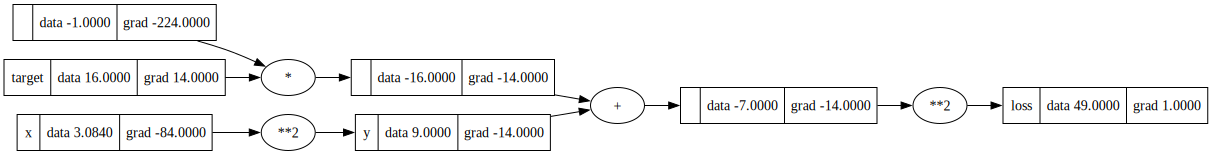

iter 1: x=3.1640, y=9.5111, loss=42.1064


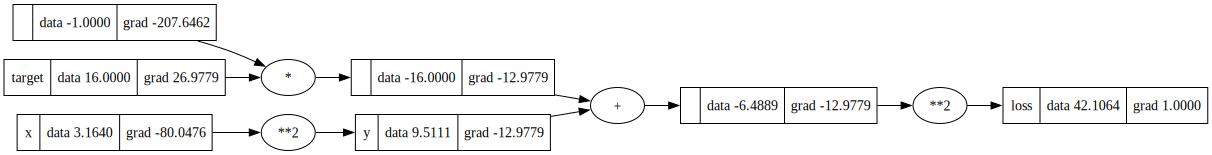

iter 2: x=3.2398, y=10.0112, loss=35.8658


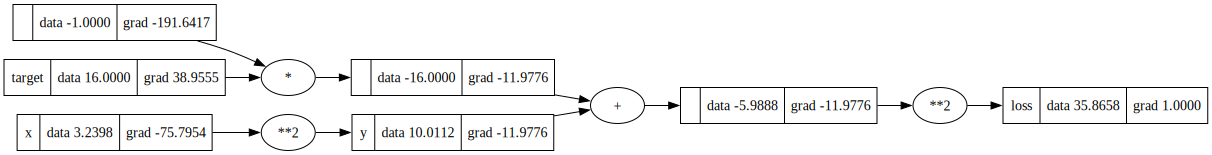

iter 3: x=3.3112, y=10.4966, loss=30.2876


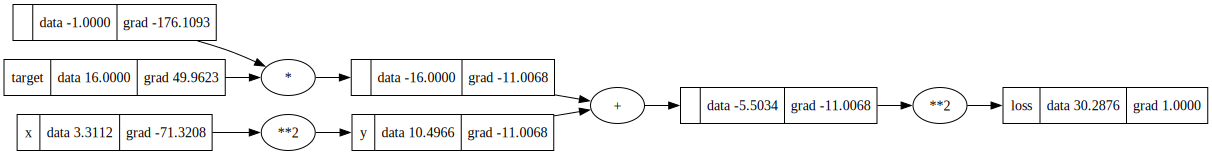

iter 4: x=3.3779, y=10.9638, loss=25.3632


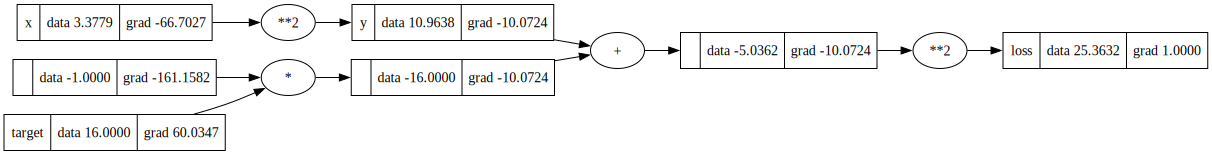

iter 5: x=3.4399, y=11.4100, loss=21.0683


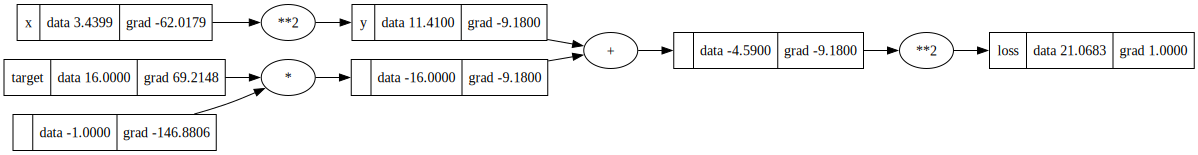

iter 6: x=3.4972, y=11.8328, loss=17.3655


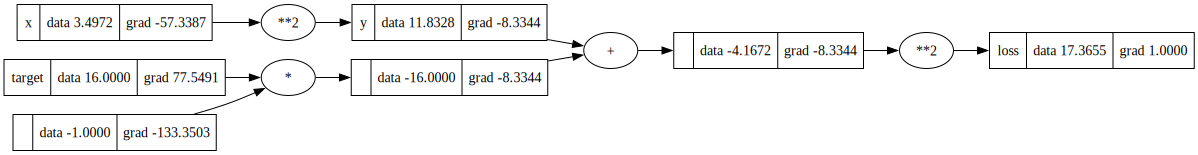

iter 7: x=3.5500, y=12.2306, loss=14.2086


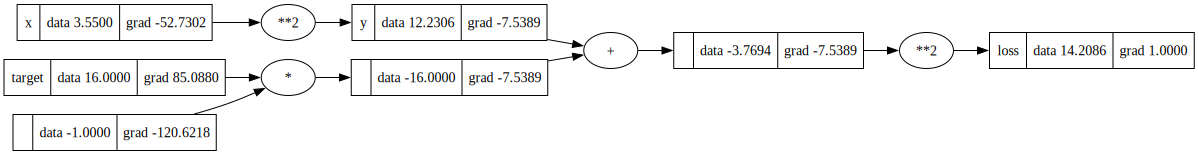

iter 8: x=3.5982, y=12.6022, loss=11.5453


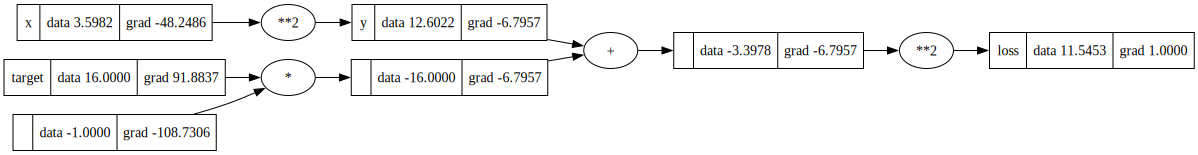

iter 9: x=3.6421, y=12.9471, loss=9.3205


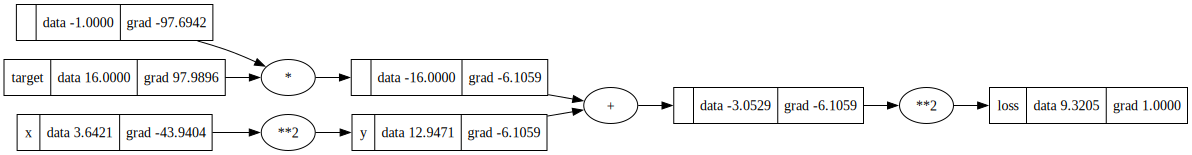

In [75]:
import random
from graphviz import Digraph

# ---------------- TRACE ----------------
def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


# ---------------- DRAW ----------------
def draw_dot(root):
    dot = Digraph(format='png', graph_attr={'rankdir': 'LR'})
    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))

        dot.node(
            name=uid,
            label="{ %s | data %.4f | grad %.4f }" %
                  (n.label, n.data, n.grad),
            shape="record"
        )

        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        if n2._op:
            dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot


# ---------------- VALUE ----------------
class Value:
    """stores scalar value + gradient"""

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    # ---- add ----
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)

        out = Value(
            self.data + other.data,
            (self, other),
            '+'
        )

        def _backward():
            self.grad += out.grad
            other.grad += out.grad

        out._backward = _backward
        return out

    # ---- multiply ----
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)

        out = Value(
            self.data * other.data,
            (self, other),
            '*'
        )

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        return out

    # ---- power ----
    def __pow__(self, other):
        assert isinstance(other, (int, float))

        out = Value(
            self.data ** other,
            (self,),
            f'**{other}'
        )

        def _backward():
            self.grad += (
                other * self.data ** (other - 1)
            ) * out.grad

        out._backward = _backward
        return out

    # ---- relu ----
    def relu(self):
        out = Value(
            0 if self.data < 0 else self.data,
            (self,),
            'ReLU'
        )

        def _backward():
            self.grad += (out.data > 0) * out.grad

        out._backward = _backward
        return out

    # ---- backward ----
    def backward(self):
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)

        self.grad = 1.0
        for v in reversed(topo):
            v._backward()

    # ---- helpers ----
    def __neg__(self):
        return self * -1

    def __radd__(self, other):
        return self + other

    def __sub__(self, other):
        return self + (-other)

    def __rsub__(self, other):
        return other + (-self)

    def __rmul__(self, other):
        return self * other

    def __truediv__(self, other):
        return self * other**-1

    def __rtruediv__(self, other):
        return other * self**-1

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"


# ---------------- SIMPLE TRAINING ----------------
# optimize x so x² ≈ 16

x = Value(3.0, label='x')
target = Value(16.0, label='target')

lr = 0.001

for i in range(10):
    x.grad = 0

    # forward
    y = x**2
    y.label = 'y'

    loss = (y - target)**2
    loss.label = 'loss'

    # backward
    loss.backward()

    # gradient descent
    x.data -= lr * x.grad

    print(
        f"iter {i}: "
        f"x={x.data:.4f}, "
        f"y={y.data:.4f}, "
        f"loss={loss.data:.4f}"
    )

    display(draw_dot(loss))

iter 0: y=0.0000, loss=64.0000, w1=0.8200, w2=-0.5200, b=2.1600


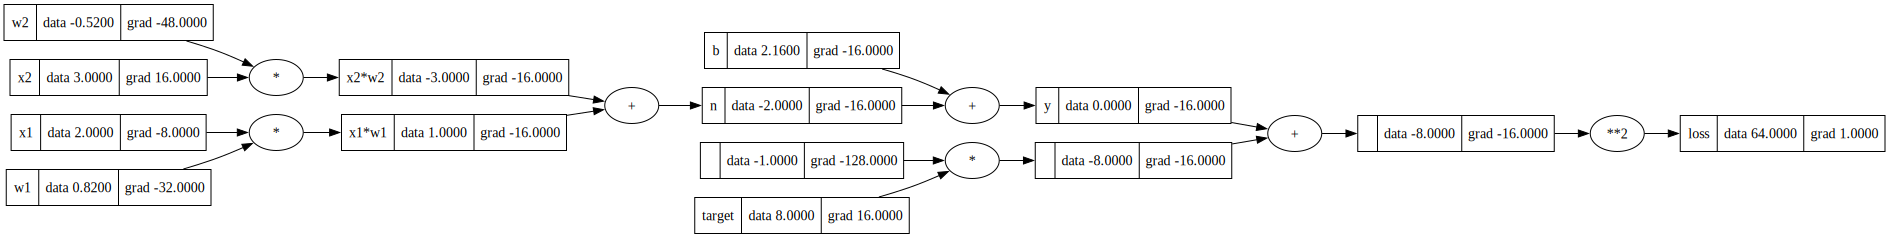

iter 1: y=2.2400, loss=33.1776, w1=1.0504, w2=-0.1744, b=2.2752


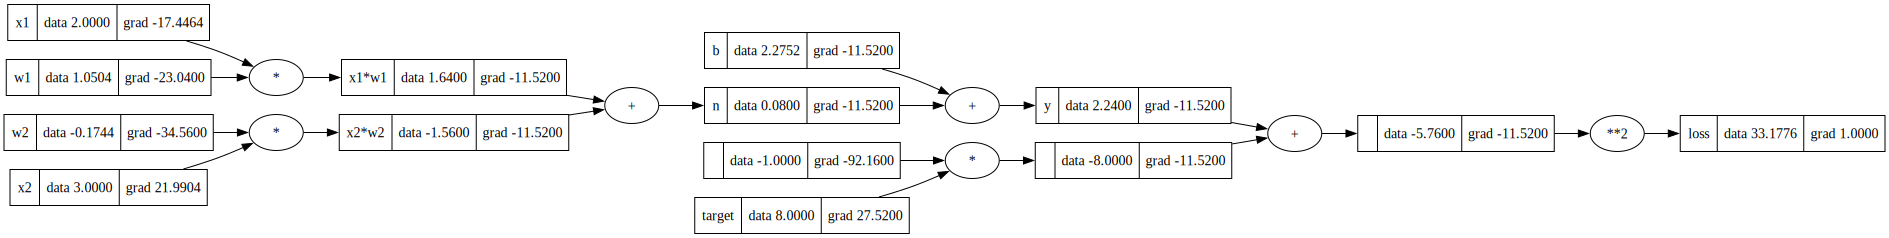

iter 2: y=3.8528, loss=17.1993, w1=1.2163, w2=0.0744, b=2.3581


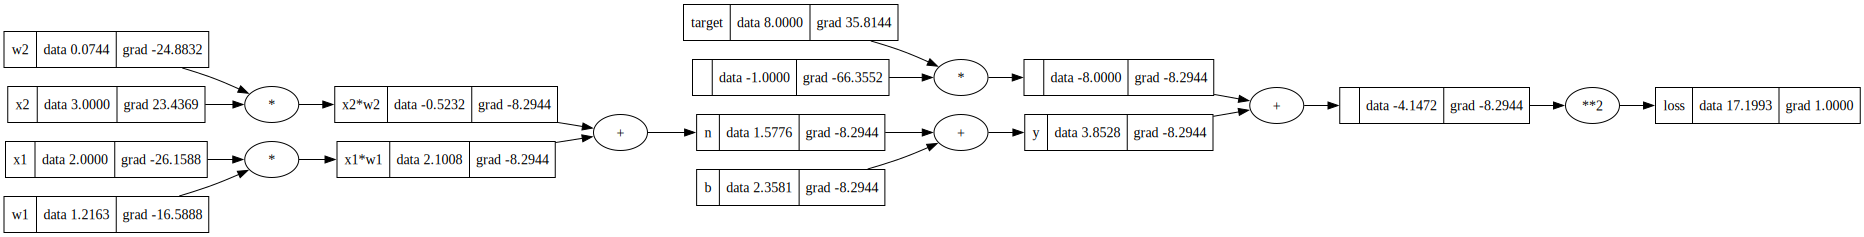

iter 3: y=5.0140, loss=8.9161, w1=1.3357, w2=0.2536, b=2.4179


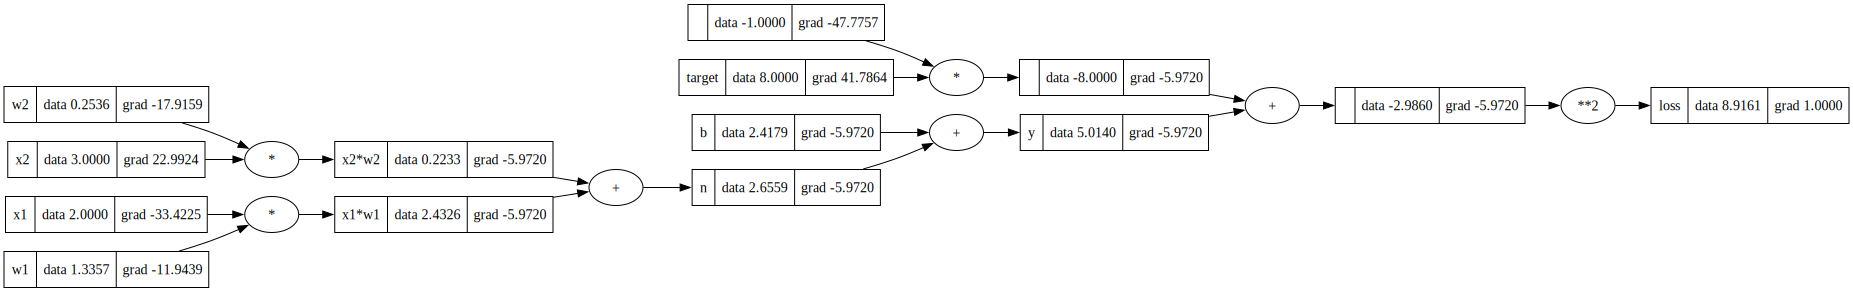

iter 4: y=5.8501, loss=4.6221, w1=1.4217, w2=0.3826, b=2.4609


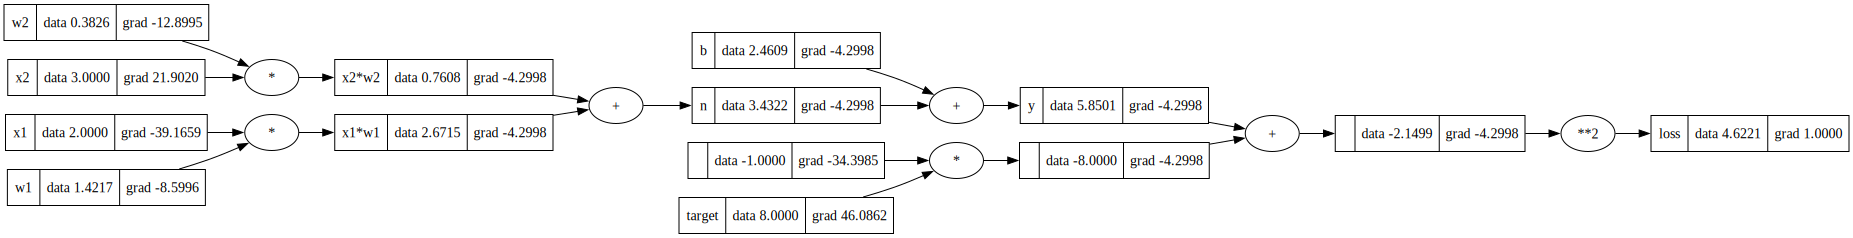

iter 5: y=6.4521, loss=2.3961, w1=1.4836, w2=0.4755, b=2.4918


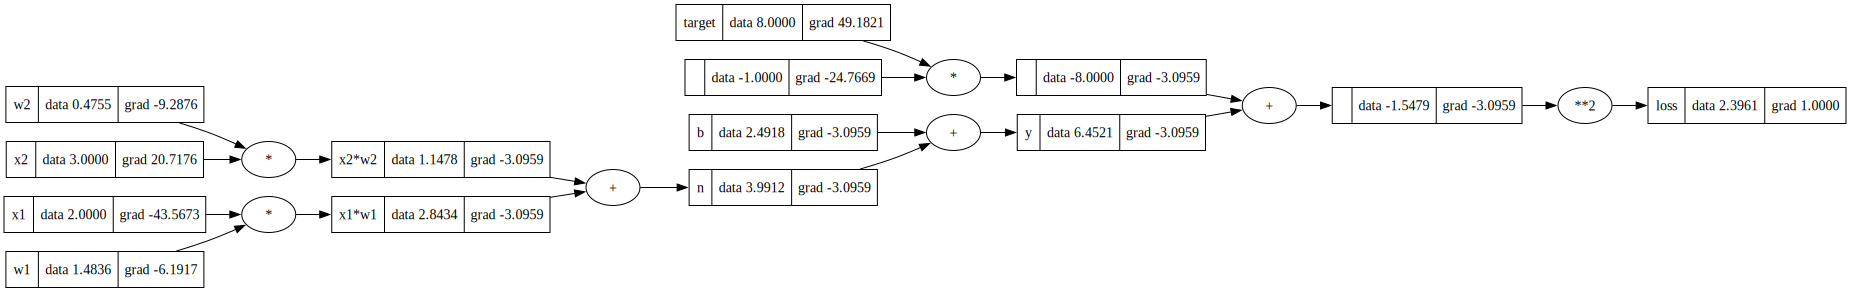

iter 6: y=6.8855, loss=1.2421, w1=1.5282, w2=0.5423, b=2.5141


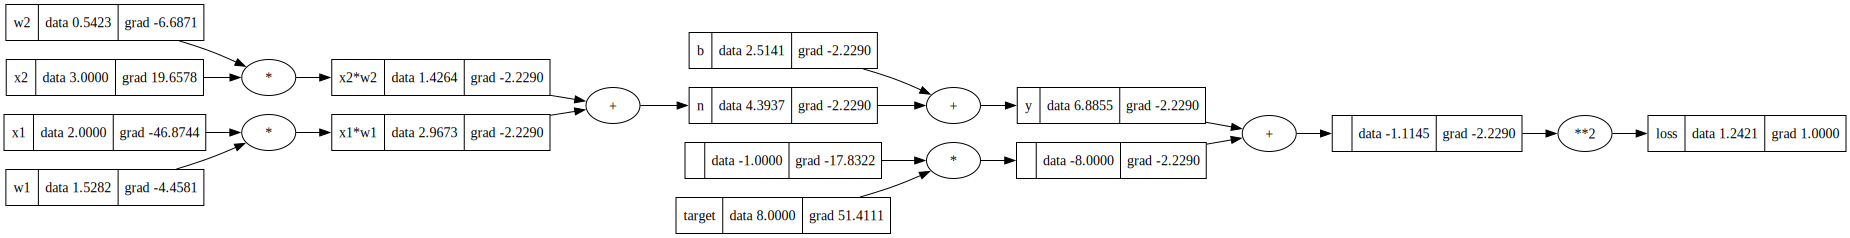

iter 7: y=7.1976, loss=0.6439, w1=1.5603, w2=0.5905, b=2.5302


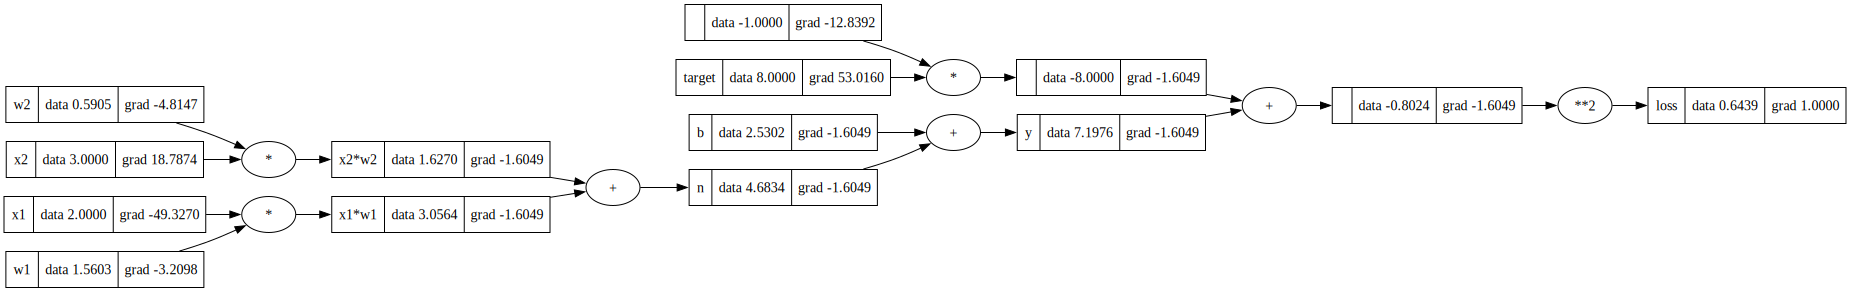

iter 8: y=7.4222, loss=0.3338, w1=1.5834, w2=0.6251, b=2.5417


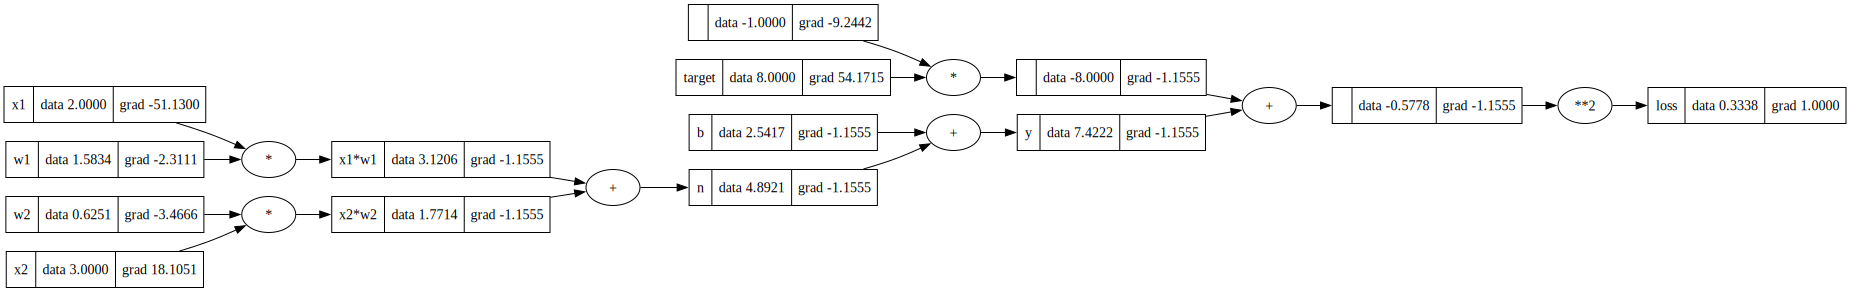

iter 9: y=7.5840, loss=0.1730, w1=1.6001, w2=0.6501, b=2.5500


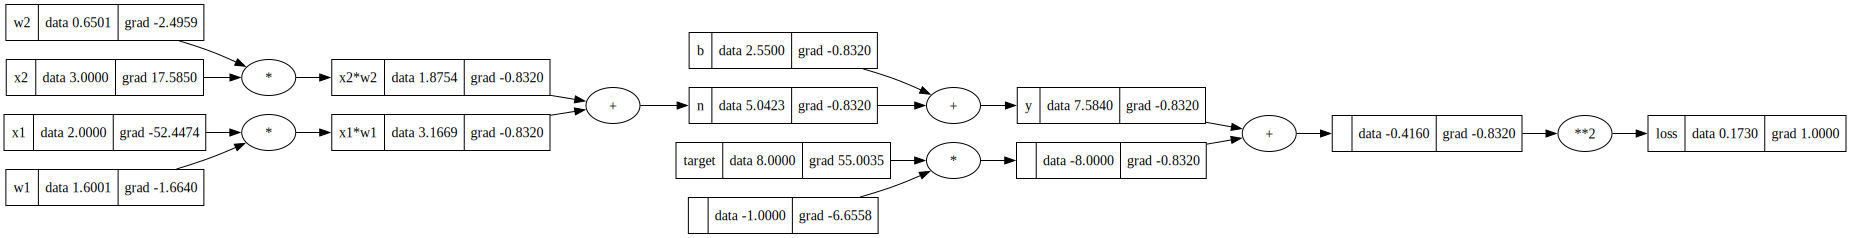

In [76]:
# -------- TRAIN WEIGHTS --------

# parameters
w1 = Value(0.5, label='w1')
w2 = Value(-1.0, label='w2')
b  = Value(2.0, label='b')

# fixed inputs
x1 = Value(2.0, label='x1')
x2 = Value(3.0, label='x2')

target = Value(8.0, label='target')

lr = 0.01

for i in range(10):

    # zero grads
    w1.grad = w2.grad = b.grad = 0

    # -------- FORWARD --------
    x1w1 = x1 * w1
    x1w1.label = 'x1*w1'

    x2w2 = x2 * w2
    x2w2.label = 'x2*w2'

    n = x1w1 + x2w2
    n.label = 'n'

    y = n + b
    y.label = 'y'

    loss = (y - target)**2
    loss.label = 'loss'

    # -------- BACKWARD --------
    loss.backward()

    # -------- GRADIENT DESCENT --------
    w1.data -= lr * w1.grad
    w2.data -= lr * w2.grad
    b.data  -= lr * b.grad

    print(
        f"iter {i}: "
        f"y={y.data:.4f}, "
        f"loss={loss.data:.4f}, "
        f"w1={w1.data:.4f}, "
        f"w2={w2.data:.4f}, "
        f"b={b.data:.4f}"
    )

    display(draw_dot(loss))

In [81]:
from graphviz import Digraph
class Value:
    def __init__(self,val,previous_vals=(),opr='',):
        self.val=val
        self.pervious_vals=set(previous_vals)
        self.opr=opr
    
    def __add__(self,other):
        output=(self.val + other.val)
        return output
    
    def __mul__(self,other):
        output=(self.val*other.val)
        return output    

a=Value(2.0)


In [82]:
b=Value(3.0)

In [83]:
a+b

5.0

In [84]:
a*b

6.0

In [ ]:
from graphviz import Digraph


def trace(root):
    nodes=set()
    edges=set()
    def  bulid(v):
      if v not in nodes:
        nodes.add(v)
        for child in v.previousvals:
           edges.add((child,v))
           bulid(child)
    bulid(root)
    return nodes,edges


def draw_dot(root):
   dot=Digraph(format='svg',graph_attr={'rankdir':'LR'})
   nodes,edges=trace(root)

   for n in nodes:
        uid=str(id(n))

        dot.node(
            name=uid,
            label="{ %s | data %.4f | grad %.4f }" %
                    (n.label, n.data, n.grad),
            shape="box3d"
        )
        if n.opr:
            dot.node(name=uid+n.opr,label=n.opr)
            dot.edge(uid+n.opr,uid)

   for n1,n2 in edges:
              if n2._op:
                    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

   return dot

class Value:
    def __init__(self,val,previousvals=(),opr='',label=''):
        self.val=val
        self.perviousvals=set(previousvals)
        self.opr=opr
        self.grad=0
        self.backward=lambda:None
        """
        def empty():
             pass

        self._backward = empty
        
        """
    
    def __add__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        # other = other if isinstance ( other , Value ) else Value ( other )
        output=Value(self.val + other.val,
                     (self,other)#creating a new node in graph of prev vals
                     ,opr="+")
        def backward(self,other):
          self.grad+=1.0*output.grad
          self.grad+=1.0*output.grad
        output.backward=backward
        return output
    
    def __mul__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        output=Value(self.val*other.val,
                     (self,other),
                     opr="*")
        def backward(self,other):
            self.grad+=other.data*output.grad
            other.grad+=self.data*output.grad
        output.backward=backward
        return output   

    def __pow__(self,other):
        assert isinstance(other,(int,float))
        output=Value( self.val**other,(self,),opr=f"**{other}")
        def backward(self,other):
            self.grad+=(other)*((self.val)**(other-1))*output.grad
        output.backward=backward
        return output
    
    def __pow__(self, other):
    assert isinstance(other, (int, float))

    output = Value(
        self.val ** other,
        (self,),
        opr=f"**{other}"
    )

    def backward():
        self.grad += other * (self.val ** (other - 1)) * output.grad

    output.backward = backward
    return output
    
    def __relu__(self):
        output=Value(0 if self.val <0 else self.val,(self,),opr="Relu")
        def backward(self):
            self.grad+=(output.val>0)*output.grad
        output.backward=backward
        return output
    def __repr__(self):
        return f"Value(val={self.val},(Grad={self.grad}))"
    
    def backward(self):
        topo=[],visited=set()
        def bulid_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v.previousvals:
                    bulid_topo(child)
                topo.append(v)

        bulid_topo(self)
        self.grad=1 
        for v in reversed(topo):
            v.backward()

    def __neg__(self): return self*-1 
    def __radd__(self,other): return self+other 
   
    def __sub__(self,other): return self+(-other)
    def __rsub__(self,other): return other+(-self) 

    def __div__(self,other): return self*(other**-1)
    def __rdiv__(self,other): return other*(self**-1)

class Module:
    def zero_grad(self):
        for p in self.parameters():
            p.grad=0

    def parameters(self): return []
class Neuron(Module) :
    def __init__(self,nin,nonlinear=True):
        self.weights=[Value(random.uniform(-1,1)) for i in range(nin)]
        self.bias=Value(0.0)
        self.nonlinear=nonlinear
    def __call__(self,x):
        activation=sum((wi*xi for wi,xi in zip(self.weights,x)),self.bias)
        return activation
    def parameters(self):
        return self.weights+[self.bias]
    def __repr__(self):
        return f"Newuron with inputs{len(self.weights)}"
class layer(Module):
    def __init__(self,nin,nouts,**kwargs):
        self.neurons= [Neuron(nin,**kwargs) for i in range((nouts))]
    def __call__(self,x):
        outputoflayer=[n(x) for n in self.neurons]
        return outputoflayer[0] if len(outputoflayer)==1 else outputoflayer
    def parameters(self):
        return [parameters for neuron in self.neurons for parameters in neuron.parameters()]
    def __repr__(self):
        return f" Layer of [{ ','. join (str(n) for n in self.neurons )}]"
class MLP(Module):
    def __init__(self,inputsize,layersL):
        multilayersl=[inputsize]+layersL
        self.multilayersl=[
                          Layer(multilayersl[i],
                                multilayersl[i+1],
                                nonlinear=(i!=len(layersL)-1))
                          for i in range(len(layersL))
                          ]
    def __call__(self,x):
        for layer in self.multilayersl:
            x=layer(x)
        return x
        
    def parameters(self):
        return [layer_params for layers in self.multilayersl for layer_params in layers.parameters()]

    def __repr__ ( self ) :
     return f"MLP of [{ ','. join (str(layer) for layer in self.multilayersl)}]"


# -------- TRAIN WEIGHTS --------

# parameters
w1 = Value(0.5, label='w1')
w2 = Value(-1.0, label='w2')
b  = Value(2.0, label='b')

# fixed inputs
x1 = Value(2.0, label='x1')
x2 = Value(3.0, label='x2')

target = Value(8.0, label='target')

lr = 0.01

for i in range(10):

    # zero grads
    w1.grad = w2.grad = b.grad = 0

    # -------- FORWARD --------
    x1w1 = x1 * w1
    x1w1.label = 'x1*w1'

    x2w2 = x2 * w2
    x2w2.label = 'x2*w2'

    n = x1w1 + x2w2
    n.label = 'n'

    y = n + b
    y.label = 'y'

    loss = (y - target)**2
    loss.label = 'loss'

    # -------- BACKWARD --------
    loss.backward()

    # -------- GRADIENT DESCENT --------
    w1.val -= lr * w1.grad
    w2.val -= lr * w2.grad
    b.val  -= lr * b.grad

    print(
        f"iter {i}: "
        f"y={y.data:.4f}, "
        f"loss={loss.data:.4f}, "
        f"w1={w1.data:.4f}, "
        f"w2={w2.data:.4f}, "
        f"b={b.data:.4f}"
    )

    display(draw_dot(loss))





TypeError: Value.__pow__.<locals>.backward() missing 2 required positional arguments: 'self' and 'other'

In [108]:
a=Value(3.0)
b=Value(2.0)
a*2


6.0

In [109]:
a

Value(3.0)

iter 0: y=0.0000, loss=64.0000, w1=0.8200, w2=-0.5200, b=2.1600
iter 1: y=2.2400, loss=33.1776, w1=1.0504, w2=-0.1744, b=2.2752
iter 2: y=3.8528, loss=17.1993, w1=1.2163, w2=0.0744, b=2.3581
iter 3: y=5.0140, loss=8.9161, w1=1.3357, w2=0.2536, b=2.4179
iter 4: y=5.8501, loss=4.6221, w1=1.4217, w2=0.3826, b=2.4609
iter 5: y=6.4521, loss=2.3961, w1=1.4836, w2=0.4755, b=2.4918
iter 6: y=6.8855, loss=1.2421, w1=1.5282, w2=0.5423, b=2.5141
iter 7: y=7.1976, loss=0.6439, w1=1.5603, w2=0.5905, b=2.5302
iter 8: y=7.4222, loss=0.3338, w1=1.5834, w2=0.6251, b=2.5417
iter 9: y=7.5840, loss=0.1730, w1=1.6001, w2=0.6501, b=2.5500


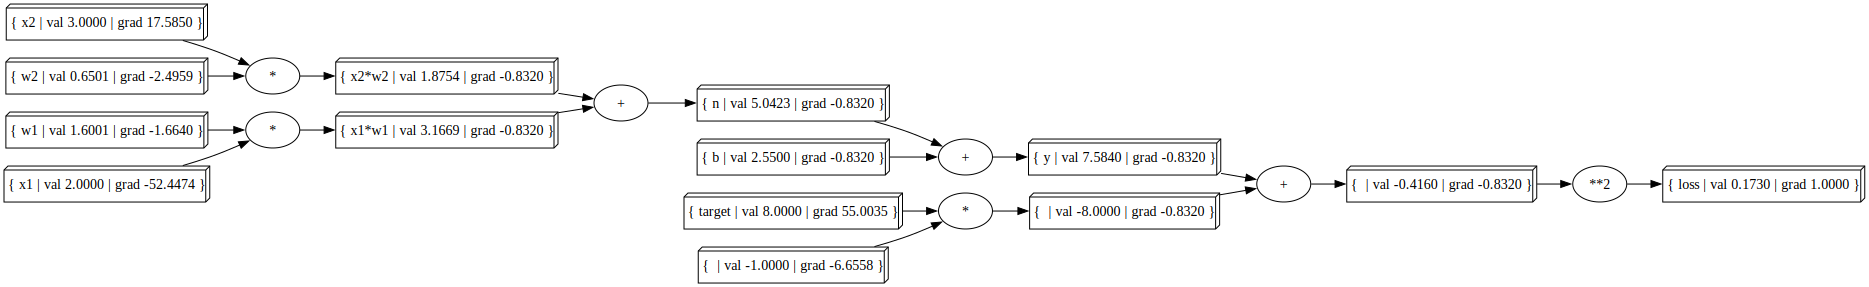

Value(val=1.6000696429414345, grad=-1.6639583300553262) Value(val=0.6501044644121514, grad=-2.4959374950829893) Value(val=2.550034821470718, grad=-0.8319791650276631)


In [ ]:
import random
from graphviz import Digraph
from IPython.display import display


def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v.prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))

        dot.node(
            name=uid,
            label="{ %s | val %.4f | grad %.4f }" %
                  (n.label, n.val, n.grad),
            shape="box3d"
        )

        if n.op:
            dot.node(name=uid + n.op, label=n.op)
            dot.edge(uid + n.op, uid)

    for n1, n2 in edges:
        if n2.op:
            dot.edge(str(id(n1)), str(id(n2)) + n2.op)

    return dot



class Value:
    def __init__(self, val, prev=(), op='', label=''):
        self.val = val
        self.grad = 0.0
        self.prev = set(prev)
        self.op = op
        self.label = label
        self._backward = lambda: None

    def __repr__(self):
        return f"Value(val={self.val}, grad={self.grad})"


    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)

        out = Value(self.val + other.val, (self, other), '+')

        def backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad

        out._backward = backward
        return out

    def __radd__(self, other):
        return self + other


    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)

        out = Value(self.val * other.val, (self, other), '*')

        def backward():
            self.grad += other.val * out.grad
            other.grad += self.val * out.grad

        out._backward = backward
        return out

    def __rmul__(self, other):
        return self * other


    def __neg__(self):
        return self * -1


    def __sub__(self, other):
        return self + (-other)

    def __rsub__(self, other):
        return other + (-self)

    def __truediv__(self, other):
        return self * (other ** -1)

    def __rtruediv__(self, other):
        return other * (self ** -1)

    def __pow__(self, other):
        assert isinstance(other, (int, float))

        out = Value(self.val ** other, (self,), f'**{other}')

        def backward():
            self.grad += other * (self.val ** (other - 1)) * out.grad

        out._backward = backward
        return out

    def relu(self):
        out = Value(0 if self.val < 0 else self.val, (self,), 'ReLU')

        def backward():
            self.grad += (out.val > 0) * out.grad

        out._backward = backward
        return out

    def backward(self):
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v.prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

class Module:
    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0.0

    def parameters(self):
        return []

class Neuron(Module):
    def __init__(self, nin, nonlinear=True):
        self.weights = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.bias = Value(0.0)
        self.nonlinear = nonlinear

    def __call__(self, x):
        act = sum((wi * xi for wi, xi in zip(self.weights, x)), self.bias)
        return act.relu() if self.nonlinear else act

    def parameters(self):
        return self.weights + [self.bias]

    def __repr__(self):
        return f"Neuron({len(self.weights)})"


class Layer(Module):
    def __init__(self, nin, nout, **kwargs):
        self.neurons = [Neuron(nin, **kwargs) for _ in range(nout)]

    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out) == 1 else out

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

    def __repr__(self):
        return f"Layer([{', '.join(str(n) for n in self.neurons)}])"


class MLP(Module):
    def __init__(self, nin, layers):
        sizes = [nin] + layers

        self.layers = [
            Layer(
                sizes[i],
                sizes[i + 1],
                nonlinear=(i != len(layers) - 1)
            )
            for i in range(len(layers))
        ]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

    def __repr__(self):
        return f"MLP([{', '.join(str(l) for l in self.layers)}])"


w1 = Value(0.5, label='w1')
w2 = Value(-1.0, label='w2')
b = Value(2.0, label='b')

x1 = Value(2.0, label='x1')
x2 = Value(3.0, label='x2')

target = Value(8.0, label='target')
lr = 0.01

for i in range(10):
    # zero gradients
    w1.grad = w2.grad = b.grad = 0.0

    # forward
    x1w1 = x1 * w1
    x1w1.label = 'x1*w1'

    x2w2 = x2 * w2
    x2w2.label = 'x2*w2'

    n = x1w1 + x2w2
    n.label = 'n'

    y = n + b
    y.label = 'y'

    loss = (y - target) ** 2
    loss.label = 'loss'

    # backward
    loss.backward()

    # gradient descent
    w1.val -= lr * w1.grad
    w2.val -= lr * w2.grad
    b.val -= lr * b.grad

    print(
        f"iter {i}: "
        f"y={y.val:.4f}, "
        f"loss={loss.val:.4f}, "
        f"w1={w1.val:.4f}, "
        f"w2={w2.val:.4f}, "
        f"b={b.val:.4f}"
    )

display(draw_dot(loss))
print(w1,w2,b)

In [2]:
!pip install graphviz

  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
Using cached graphviz-0.21-py3-none-any.whl (47 kB)



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


iter 0: y=0.0000, loss=64.0000, w1=0.8200, w2=-0.5200, b=2.1600


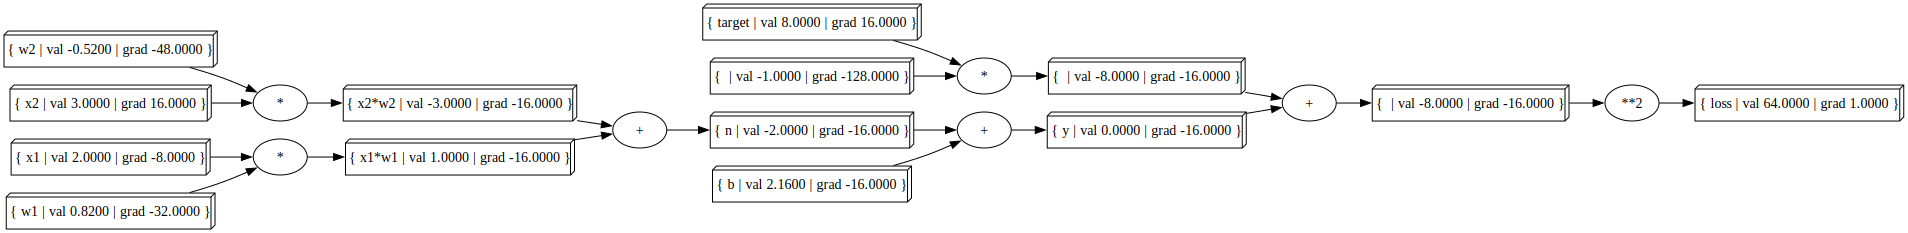

iter 1: y=2.2400, loss=33.1776, w1=1.0504, w2=-0.1744, b=2.2752


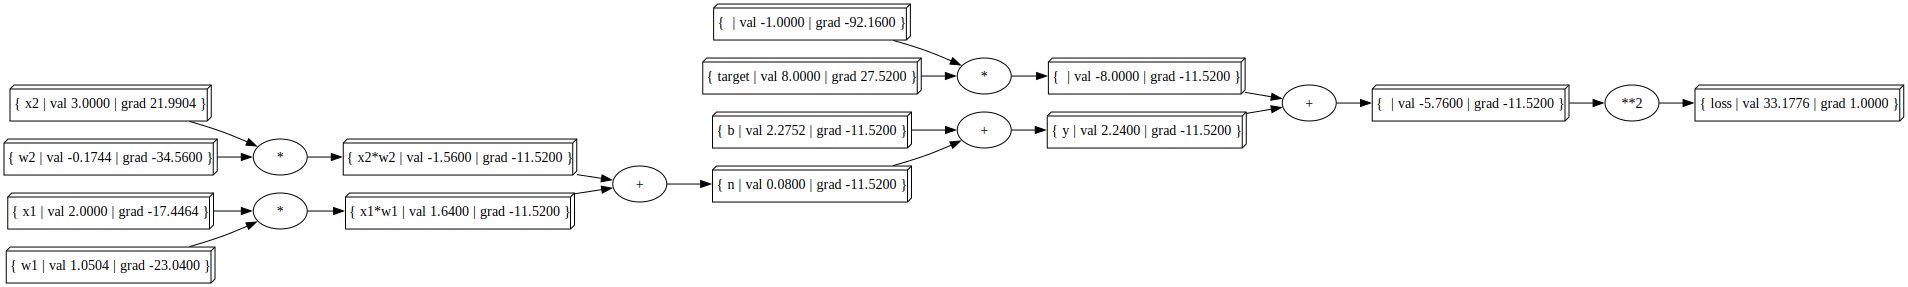

iter 2: y=3.8528, loss=17.1993, w1=1.2163, w2=0.0744, b=2.3581


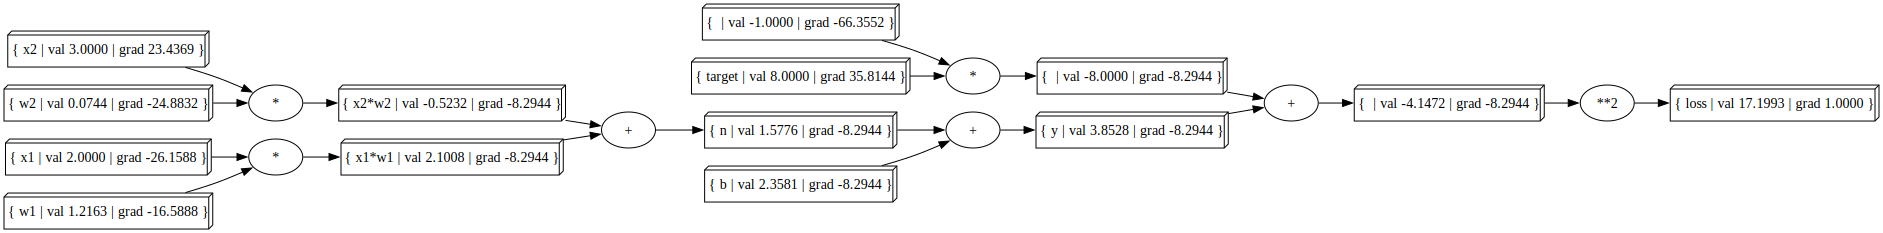

iter 3: y=5.0140, loss=8.9161, w1=1.3357, w2=0.2536, b=2.4179


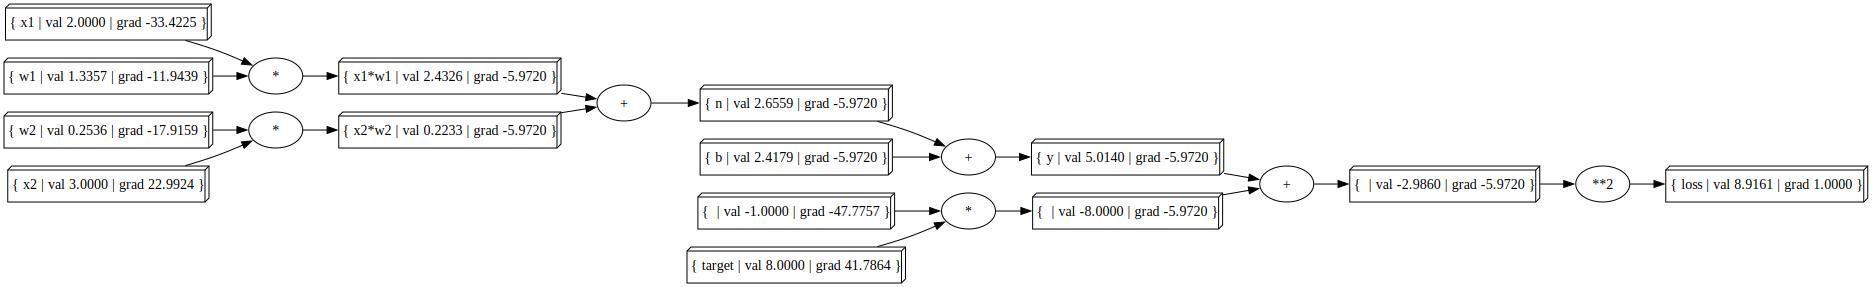

iter 4: y=5.8501, loss=4.6221, w1=1.4217, w2=0.3826, b=2.4609


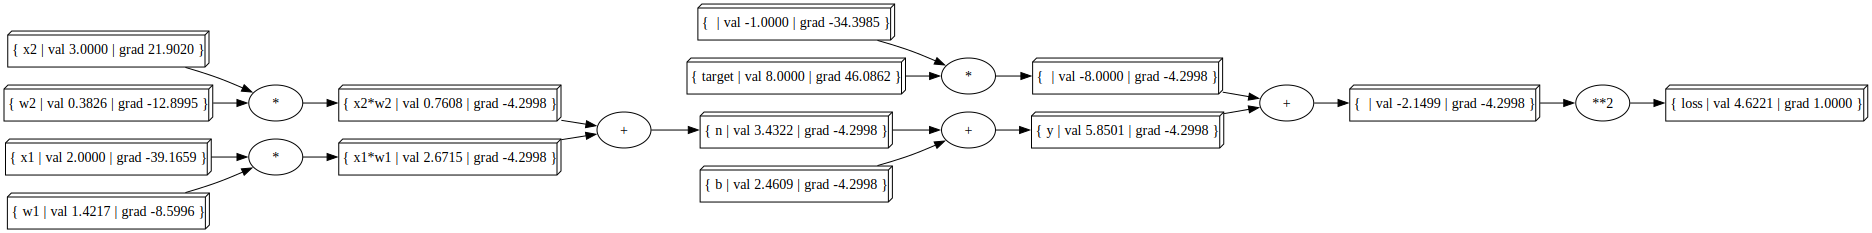

iter 5: y=6.4521, loss=2.3961, w1=1.4836, w2=0.4755, b=2.4918


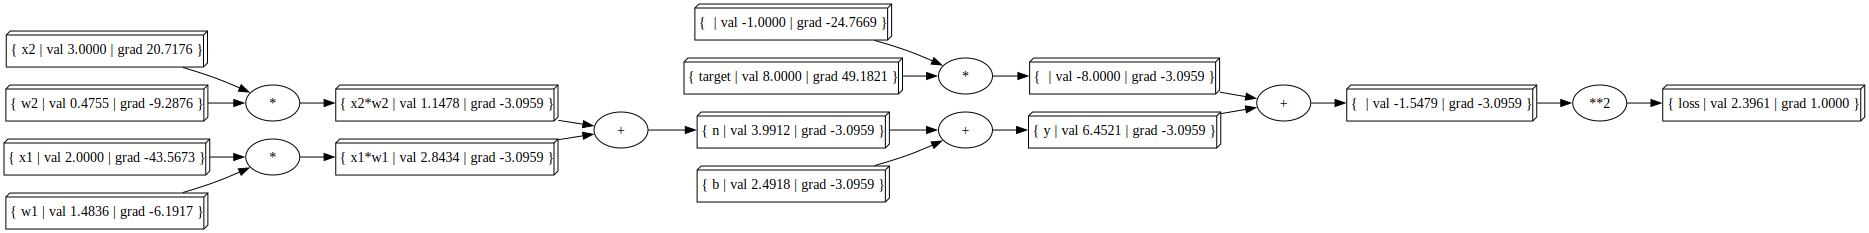

iter 6: y=6.8855, loss=1.2421, w1=1.5282, w2=0.5423, b=2.5141


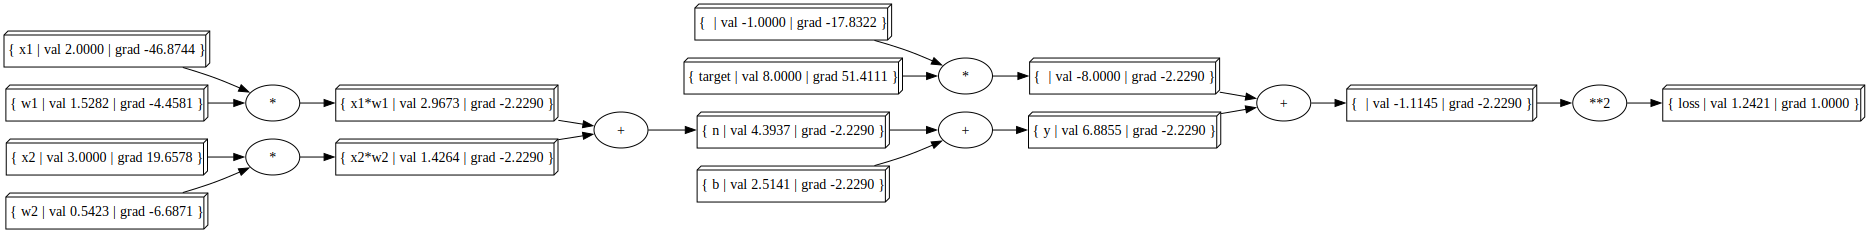

iter 7: y=7.1976, loss=0.6439, w1=1.5603, w2=0.5905, b=2.5302


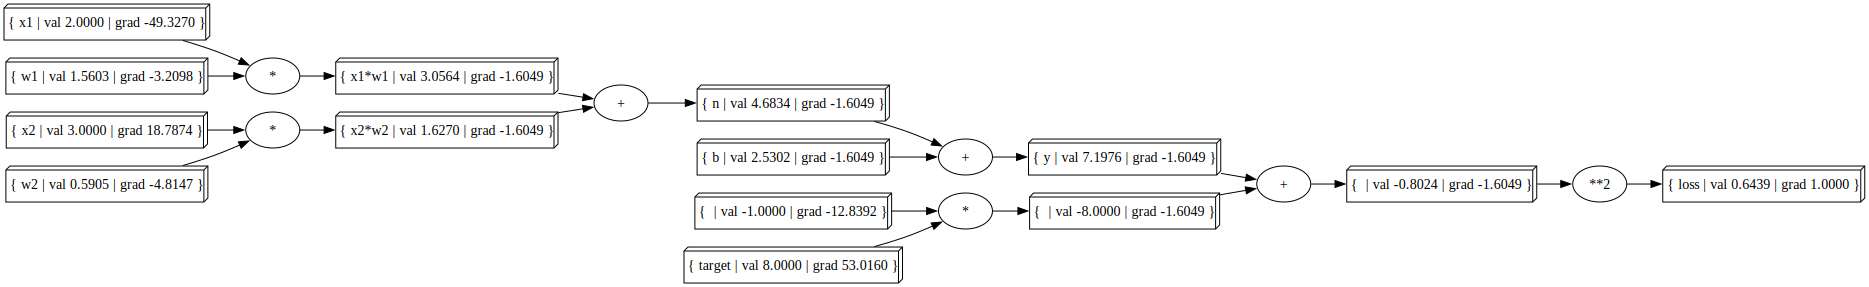

iter 8: y=7.4222, loss=0.3338, w1=1.5834, w2=0.6251, b=2.5417


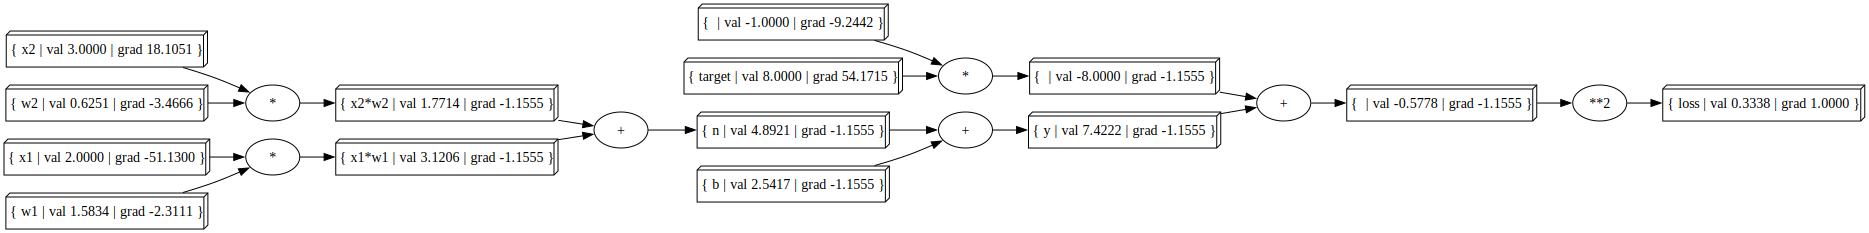

iter 9: y=7.5840, loss=0.1730, w1=1.6001, w2=0.6501, b=2.5500


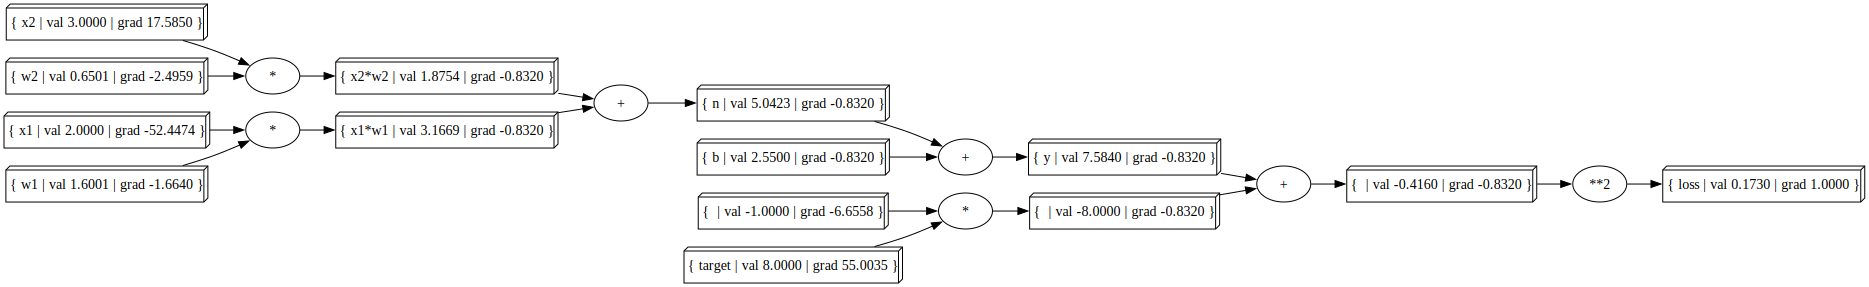

In [24]:
import random
from graphviz import Digraph
from IPython.display import display


def trace(root):
    nodes=set()
    edges=set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v.prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes,edges


def draw_dot(root):
    dot=Digraph(format='svg',graph_attr={'rankdir':'LR'})
    nodes,edges=trace(root)

    for n in nodes:
        uid=str(id(n))

        dot.node(
            name=uid,
            label="{ %s | val %.4f | grad %.4f }" %
                    (n.label, n.val, n.grad),
            shape="box3d"
        )
        if n.op:
            dot.node(name=uid+n.op,label=n.op)
            dot.edge(uid+n.op,uid)

    for n1,n2 in edges:
        if n2.op:
            dot.edge(str(id(n1)), str(id(n2)) + n2.op)

    return dot


class Value:
    def __init__(self,val,prev=(),op='',label=''):
        self.val=val
        self.prev=set(prev)
        self.op=op
        self.label=label
        self.grad=0.0
        self._backward=lambda:None

    def __add__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        output=Value(self.val + other.val,
                     (self,other),
                     op="+")
        def backward():
            self.grad  += 1.0 * output.grad
            other.grad += 1.0 * output.grad
        output._backward=backward
        return output

    def __mul__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        output=Value(self.val * other.val,
                     (self,other),
                     op="*")
        def backward():
            self.grad  += other.val * output.grad
            other.grad += self.val  * output.grad
        output._backward=backward
        return output

    def __pow__(self,other):
        assert isinstance(other,(int,float))
        output=Value(self.val**other,(self,),op=f"**{other}")
        def backward():
            self.grad += (other) * (self.val**(other-1)) * output.grad
        output._backward=backward
        return output

    def relu(self):
        output=Value(0 if self.val < 0 else self.val,(self,),op="Relu")
        def backward():
            self.grad += (output.val > 0) * output.grad
        output._backward=backward
        return output

    def __neg__(self): return self*-1
    def __radd__(self,other): return self+other
    def __sub__(self,other): return self+(-other)
    def __rsub__(self,other): return other+(-self)
    def __truediv__(self,other): return self*(other**-1)
    def __rtruediv__(self,other): return other*(self**-1)

    def backward(self):
        topo=[]
        visited=set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v.prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad=1.0
        for v in reversed(topo):
            v._backward()

    def __repr__(self):
        return f"Value(val={self.val},(Grad={self.grad}))"


class Module:
    def zero_grad(self):
        for p in self.parameters():
            p.grad=0
    def parameters(self): return []

class Params(Module):
    def __init__(self,*vals):
        self.vals=list(vals)
    def parameters(self):
        return self.vals


class Neuron(Module):
    def __init__(self,nin,nonlinear=True):
        self.weights=[Value(random.uniform(-1,1)) for i in range(nin)]
        self.bias=Value(0.0)
        self.nonlinear=nonlinear
    def __call__(self,x):
        activation=sum((wi*xi for wi,xi in zip(self.weights,x)),self.bias)
        return activation.relu() if self.nonlinear else activation
    def parameters(self):
        return self.weights+[self.bias]
    def __repr__(self):
        return f"Neuron with inputs {len(self.weights)}"


class Layer(Module):
    def __init__(self,nin,nouts,**kwargs):
        self.neurons=[Neuron(nin,**kwargs) for i in range(nouts)]
    def __call__(self,x):
        outputoflayer=[n(x) for n in self.neurons]
        return outputoflayer[0] if len(outputoflayer)==1 else outputoflayer
    def parameters(self):
        return [parameters for neuron in self.neurons for parameters in neuron.parameters()]
    def __repr__(self):
        return f"Layer of [{ ','.join(str(n) for n in self.neurons)}]"


class MLP(Module):
    def __init__(self,inputsize,layersL):
        multilayersl=[inputsize]+layersL
        self.multilayersl=[
                          Layer(multilayersl[i],
                                multilayersl[i+1],
                                nonlinear=(i!=len(layersL)-1))
                          for i in range(len(layersL))
                          ]
    def __call__(self,x):
        for layer in self.multilayersl:
            x=layer(x)
        return x
    def parameters(self):
        return [layer_params for layers in self.multilayersl for layer_params in layers.parameters()]
    def __repr__(self):
        return f"MLP of [{ ','.join(str(layer) for layer in self.multilayersl)}]"


w1 = Value(0.5, label='w1')
w2 = Value(-1.0, label='w2')
b  = Value(2.0, label='b')

x1 = Value(2.0, label='x1')
x2 = Value(3.0, label='x2')

target = Value(8.0, label='target')

lr = 0.01
params = Params(w1, w2, b)

for i in range(10):

    params.zero_grad()

    # -------- FORWARD --------
    x1w1 = x1 * w1
    x1w1.label = 'x1*w1'

    x2w2 = x2 * w2
    x2w2.label = 'x2*w2'

    n = x1w1 + x2w2
    n.label = 'n'

    y = n + b
    y.label = 'y'

    loss = (y - target)**2
    loss.label = 'loss'

    loss.backward()

    
    w1.val -= lr * w1.grad
    w2.val -= lr * w2.grad
    b.val  -= lr * b.grad

    print(
        f"iter {i}: "
        f"y={y.val:.4f}, "
        f"loss={loss.val:.4f}, "
        f"w1={w1.val:.4f}, "
        f"w2={w2.val:.4f}, "
        f"b={b.val:.4f}"
    )

    display(draw_dot(loss))


# # Random Neural Network
# net = MLP(2, [4, 4, 1])   # 2 inputs -> 4 -> 4 -> 1 output

# # Training data
# xs = [
#     [2.0, 3.0],
#     [1.0, -1.0],
#     [0.5, 2.0],
#     [3.0, 1.0]
# ]

# ys = [8.0, 1.0, 4.0, 7.0]

# lr = 0.01

# for k in range(100):

#     # Forward pass
#     preds = [net(x) for x in xs]

#     losses = [(pred - ygt) ** 2 for pred, ygt in zip(preds, ys)]
#     loss = sum(losses)

#     # Backward pass
#     net.zero_grad()
#     loss.backward()

#     # Update parameters
#     for p in net.parameters():
#         p.val -= lr * p.grad

#     if k % 10 == 0:
#         print(f"iter {k}: loss = {loss.val:.4f}")

# # Test
# for x in xs:
#     print(x, "->", net(x).val)

# display(draw_dot(loss))

loss = 64.0
x1.grad = -8.0
x2.grad = 16.0
w1.grad = -32.0
w2.grad = -48.0
b.grad = -16.0


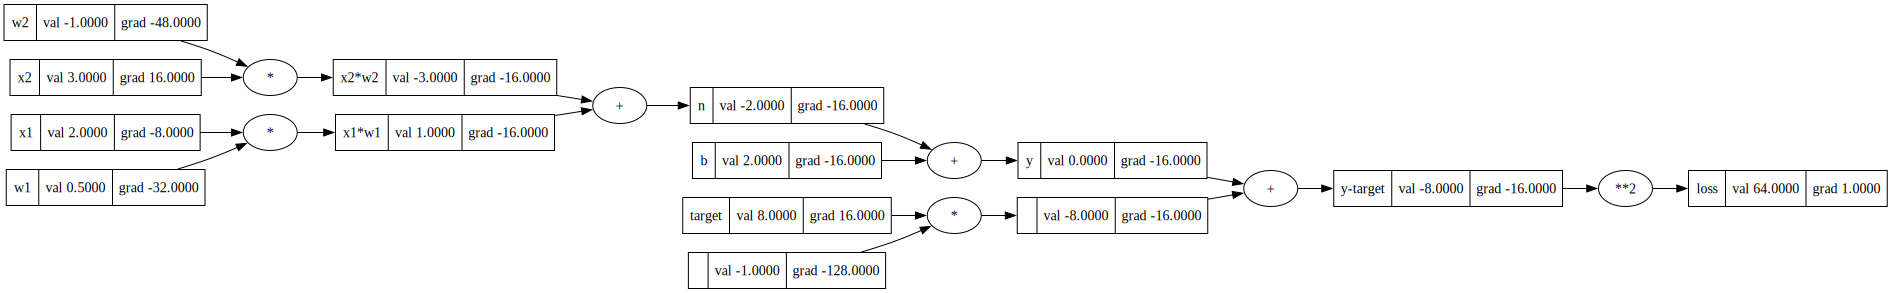

In [25]:
from graphviz import Digraph
from IPython.display import display

# ---------------- VALUE ----------------

class Value:

    def __init__(self, val, prev=(), op='', label=''):
        self.val = val
        self.prev = tuple(prev)
        self.op = op
        self.label = label

        self.grad = 0.0
        self._backward = lambda: None

    def __add__(self, other):

        other = other if isinstance(other, Value) else Value(other)

        out = Value(
            self.val + other.val,
            (self, other),
            '+'
        )

        def backward():
            self.grad += out.grad
            other.grad += out.grad

        out._backward = backward
        return out

    def __mul__(self, other):

        other = other if isinstance(other, Value) else Value(other)

        out = Value(
            self.val * other.val,
            (self, other),
            '*'
        )

        def backward():
            self.grad += other.val * out.grad
            other.grad += self.val * out.grad

        out._backward = backward
        return out

    def __pow__(self, other):

        assert isinstance(other, (int, float))

        out = Value(
            self.val ** other,
            (self,),
            f'**{other}'
        )

        def backward():
            self.grad += (
                other *
                self.val**(other-1) *
                out.grad
            )

        out._backward = backward
        return out

    def backward(self):

        topo = []
        visited = set()

        def build(v):
            if v not in visited:
                visited.add(v)

                for child in v.prev:
                    build(child)

                topo.append(v)

        build(self)

        for node in topo:
            node.grad = 0.0

        self.grad = 1.0

        for node in reversed(topo):
            node._backward()

    def __neg__(self):
        return self * -1

    def __radd__(self, other):
        return self + other

    def __sub__(self, other):
        return self + (-other)

    def __rsub__(self, other):
        return other + (-self)

    def __repr__(self):
        return f"Value(val={self.val}, grad={self.grad})"


# ---------------- GRAPH ----------------

def trace(root):

    nodes = set()
    edges = set()

    def build(v):
        if v not in nodes:
            nodes.add(v)

            for child in v.prev:
                edges.add((child, v))
                build(child)

    build(root)

    return nodes, edges


def draw_dot(root):

    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)

    for n in nodes:

        uid = str(id(n))

        dot.node(
            uid,
            label="{ %s | val %.4f | grad %.4f }"
            % (n.label, n.val, n.grad),
            shape="record"
        )

        if n.op:
            dot.node(uid + n.op, label=n.op)
            dot.edge(uid + n.op, uid)

    for n1, n2 in edges:

        if n2.op:
            dot.edge(
                str(id(n1)),
                str(id(n2)) + n2.op
            )

    return dot


# ---------------- EXAMPLE ----------------

x1 = Value(2.0, label='x1')
x2 = Value(3.0, label='x2')

w1 = Value(0.5, label='w1')
w2 = Value(-1.0, label='w2')

b = Value(2.0, label='b')

target = Value(8.0, label='target')

# forward

x1w1 = x1 * w1
x1w1.label = 'x1*w1'

x2w2 = x2 * w2
x2w2.label = 'x2*w2'

n = x1w1 + x2w2
n.label = 'n'

y = n + b
y.label = 'y'

diff = y - target
diff.label = 'y-target'

loss = diff ** 2
loss.label = 'loss'

# backward

loss.backward()

print("loss =", loss.val)

print("x1.grad =", x1.grad)
print("x2.grad =", x2.grad)

print("w1.grad =", w1.grad)
print("w2.grad =", w2.grad)

print("b.grad =", b.grad)

display(draw_dot(loss))

iter  10 | loss = 0.173047 | w1=1.6001  w2=0.6501  b=2.5500
iter  20 | loss = 0.000243 | w1=1.6413  w2=0.7119  b=2.5706
iter  30 | loss = 0.000000 | w1=1.6428  w2=0.7142  b=2.5714
iter  40 | loss = 0.000000 | w1=1.6429  w2=0.7143  b=2.5714
iter  50 | loss = 0.000000 | w1=1.6429  w2=0.7143  b=2.5714
iter  60 | loss = 0.000000 | w1=1.6429  w2=0.7143  b=2.5714
iter  70 | loss = 0.000000 | w1=1.6429  w2=0.7143  b=2.5714
iter  80 | loss = 0.000000 | w1=1.6429  w2=0.7143  b=2.5714
iter  90 | loss = 0.000000 | w1=1.6429  w2=0.7143  b=2.5714
iter 100 | loss = 0.000000 | w1=1.6429  w2=0.7143  b=2.5714


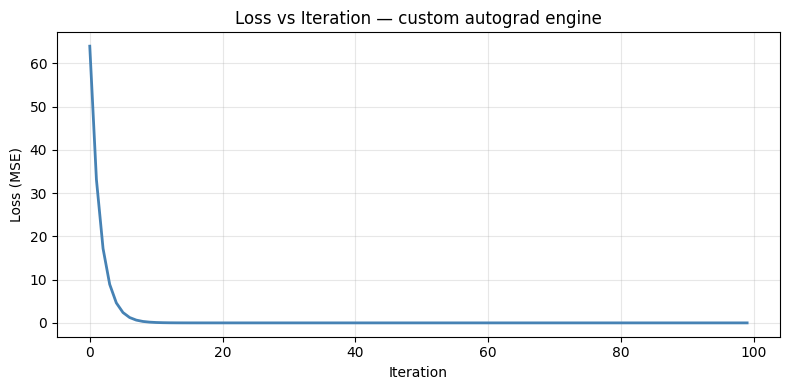


Final weights:  w1 = 1.6429  w2 = 0.7143  b = 2.5714


In [1]:
from graphviz import Digraph
import matplotlib.pyplot as plt

# ---------------- VALUE ----------------

class Value:
    def __init__(self, val, prev=(), op='', label=''):
        self.val = val
        self.prev = tuple(prev)
        self.op = op
        self.label = label
        self.grad = 0.0
        self._backward = lambda: None

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.val + other.val, (self, other), '+')
        def backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.val * other.val, (self, other), '*')
        def backward():
            self.grad += other.val * out.grad
            other.grad += self.val * out.grad
        out._backward = backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float))
        out = Value(self.val ** other, (self,), f'**{other}')
        def backward():
            self.grad += (other * self.val ** (other - 1) * out.grad)
        out._backward = backward
        return out

    def backward(self):
        topo = []
        visited = set()
        def build(v):
            if v not in visited:
                visited.add(v)
                for child in v.prev:
                    build(child)
                topo.append(v)
        build(self)
        for node in topo:
            node.grad = 0.0
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

    def __neg__(self):        return self * -1
    def __radd__(self, other): return self + other
    def __sub__(self, other):  return self + (-other)
    def __rsub__(self, other): return other + (-self)
    def __repr__(self):
        return f"Value(val={self.val}, grad={self.grad})"


# ---------------- TRAINING LOOP WITH LOSS PLOT ----------------

# Parameters (learnable)
w1 = Value(0.5,  label='w1')
w2 = Value(-1.0, label='w2')
b  = Value(2.0,  label='b')

# Fixed inputs and target
x1 = Value(2.0, label='x1')
x2 = Value(3.0, label='x2')
target = Value(8.0, label='target')

lr = 0.01        # learning rate
n_iters = 100    # number of gradient descent steps
loss_history = []

for i in range(n_iters):

    # ---- forward pass ----
    x1w1 = x1 * w1
    x2w2 = x2 * w2
    n    = x1w1 + x2w2
    y    = n + b
    diff = y - target
    loss = diff ** 2

    # ---- backward pass ----
    loss.backward()

    loss_history.append(loss.val)

    # ---- gradient descent update (manual) ----
    w1.val -= lr * w1.grad
    w2.val -= lr * w2.grad
    b.val  -= lr * b.grad

    if (i + 1) % 10 == 0:
        print(f"iter {i+1:3d} | loss = {loss.val:.6f} | "
              f"w1={w1.val:.4f}  w2={w2.val:.4f}  b={b.val:.4f}")

# ---- plot ----
plt.figure(figsize=(8, 4))
plt.plot(loss_history, color='steelblue', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Loss (MSE)')
plt.title('Loss vs Iteration — custom autograd engine')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)
plt.show()
print("\nFinal weights:  w1 =", round(w1.val, 4),
      " w2 =", round(w2.val, 4), " b =", round(b.val, 4))

In [2]:
"""
Unit tests: custom Value engine  vs  PyTorch autograd
Run with:  python test_vs_pytorch.py   (needs torch installed)
"""

import unittest
import torch


# ------------------------------------------------------------------ #
#  Paste the Value class here (or import it from your module)         #
# ------------------------------------------------------------------ #

class Value:
    def __init__(self, val, prev=(), op='', label=''):
        self.val = val
        self.prev = tuple(prev)
        self.op = op
        self.label = label
        self.grad = 0.0
        self._backward = lambda: None

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.val + other.val, (self, other), '+')
        def backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.val * other.val, (self, other), '*')
        def backward():
            self.grad += other.val * out.grad
            other.grad += self.val * out.grad
        out._backward = backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float))
        out = Value(self.val ** other, (self,), f'**{other}')
        def backward():
            self.grad += (other * self.val ** (other - 1) * out.grad)
        out._backward = backward
        return out

    def backward(self):
        topo, visited = [], set()
        def build(v):
            if v not in visited:
                visited.add(v)
                for child in v.prev:
                    build(child)
                topo.append(v)
        build(self)
        for node in topo:
            node.grad = 0.0
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

    def __neg__(self):         return self * -1
    def __radd__(self, other): return self + other
    def __sub__(self, other):  return self + (-other)
    def __rsub__(self, other): return other + (-self)
    def __rmul__(self, other): return self * other
    def __repr__(self):        return f"Value(val={self.val}, grad={self.grad})"


# ------------------------------------------------------------------ #
#  Helper                                                              #
# ------------------------------------------------------------------ #

TOL = 1e-5   # tolerance for float comparisons

def pt(*args):
    """Create a PyTorch scalar that requires grad."""
    return [torch.tensor(float(a), requires_grad=True) for a in args]


# ------------------------------------------------------------------ #
#  Tests                                                               #
# ------------------------------------------------------------------ #

class TestAddition(unittest.TestCase):

    def test_forward(self):
        a, b = Value(3.0), Value(4.0)
        self.assertAlmostEqual((a + b).val, 7.0, places=5)

    def test_backward(self):
        # d/da (a+b) = 1,  d/db (a+b) = 1
        a, b = Value(3.0), Value(4.0)
        out = a + b
        out.backward()
        ta, tb = pt(3.0, 4.0)
        (ta + tb).backward()
        self.assertAlmostEqual(a.grad, ta.grad.item(), places=5)
        self.assertAlmostEqual(b.grad, tb.grad.item(), places=5)

    def test_scalar_radd(self):
        a = Value(5.0)
        out = 3 + a
        out.backward()
        self.assertAlmostEqual(out.val, 8.0, places=5)
        self.assertAlmostEqual(a.grad, 1.0, places=5)


class TestMultiplication(unittest.TestCase):

    def test_forward(self):
        a, b = Value(3.0), Value(-2.0)
        self.assertAlmostEqual((a * b).val, -6.0, places=5)

    def test_backward(self):
        a, b = Value(3.0), Value(-2.0)
        out = a * b
        out.backward()
        ta, tb = pt(3.0, -2.0)
        (ta * tb).backward()
        self.assertAlmostEqual(a.grad, ta.grad.item(), places=5)
        self.assertAlmostEqual(b.grad, tb.grad.item(), places=5)

    def test_scalar_rmul(self):
        a = Value(4.0)
        out = 3 * a
        out.backward()
        self.assertAlmostEqual(out.val, 12.0, places=5)
        self.assertAlmostEqual(a.grad, 3.0, places=5)


class TestPower(unittest.TestCase):

    def test_square_forward(self):
        a = Value(3.0)
        self.assertAlmostEqual((a ** 2).val, 9.0, places=5)

    def test_square_backward(self):
        # d/da a^2 = 2a
        a = Value(3.0)
        (a ** 2).backward()
        ta, = pt(3.0)
        (ta ** 2).backward()
        self.assertAlmostEqual(a.grad, ta.grad.item(), places=5)

    def test_cube_backward(self):
        a = Value(2.0)
        (a ** 3).backward()
        ta, = pt(2.0)
        (ta ** 3).backward()
        self.assertAlmostEqual(a.grad, ta.grad.item(), places=5)

    def test_fractional_power(self):
        a = Value(4.0)
        (a ** 0.5).backward()
        ta, = pt(4.0)
        (ta ** 0.5).backward()
        self.assertAlmostEqual(a.grad, ta.grad.item(), places=5)

    def test_negative_power(self):
        a = Value(2.0)
        (a ** -1).backward()
        ta, = pt(2.0)
        (ta ** -1).backward()
        self.assertAlmostEqual(a.grad, ta.grad.item(), places=5)


class TestSubtraction(unittest.TestCase):

    def test_forward(self):
        a, b = Value(5.0), Value(3.0)
        self.assertAlmostEqual((a - b).val, 2.0, places=5)

    def test_backward(self):
        a, b = Value(5.0), Value(3.0)
        out = a - b
        out.backward()
        ta, tb = pt(5.0, 3.0)
        (ta - tb).backward()
        self.assertAlmostEqual(a.grad, ta.grad.item(), places=5)
        self.assertAlmostEqual(b.grad, tb.grad.item(), places=5)


class TestNegation(unittest.TestCase):

    def test_forward(self):
        a = Value(3.0)
        self.assertAlmostEqual((-a).val, -3.0, places=5)

    def test_backward(self):
        a = Value(3.0)
        (-a).backward()
        ta, = pt(3.0)
        (-ta).backward()
        self.assertAlmostEqual(a.grad, ta.grad.item(), places=5)


class TestMSELoss(unittest.TestCase):
    """Full forward + backward for the neuron in the original script."""

    def _custom(self, x1v, x2v, w1v, w2v, bv, tv):
        x1, x2 = Value(x1v), Value(x2v)
        w1, w2 = Value(w1v), Value(w2v)
        b, t   = Value(bv),  Value(tv)
        y    = x1*w1 + x2*w2 + b
        loss = (y - t) ** 2
        loss.backward()
        return loss.val, w1.grad, w2.grad, b.grad

    def _torch(self, x1v, x2v, w1v, w2v, bv, tv):
        x1, x2 = torch.tensor(x1v), torch.tensor(x2v)
        w1, w2, b = pt(w1v, w2v, bv)
        t  = torch.tensor(tv)
        y    = x1*w1 + x2*w2 + b
        loss = (y - t) ** 2
        loss.backward()
        return loss.item(), w1.grad.item(), w2.grad.item(), b.grad.item()

    def test_loss_value(self):
        cl, *_ = self._custom(2.0, 3.0, 0.5, -1.0, 2.0, 8.0)
        tl, *_ = self._torch( 2.0, 3.0, 0.5, -1.0, 2.0, 8.0)
        self.assertAlmostEqual(cl, tl, places=5)

    def test_w1_grad(self):
        _, cg, *_ = self._custom(2.0, 3.0, 0.5, -1.0, 2.0, 8.0)
        _, tg, *_ = self._torch( 2.0, 3.0, 0.5, -1.0, 2.0, 8.0)
        self.assertAlmostEqual(cg, tg, places=5)

    def test_w2_grad(self):
        _, _, cg, _ = self._custom(2.0, 3.0, 0.5, -1.0, 2.0, 8.0)
        _, _, tg, _ = self._torch( 2.0, 3.0, 0.5, -1.0, 2.0, 8.0)
        self.assertAlmostEqual(cg, tg, places=5)

    def test_bias_grad(self):
        *_, cg = self._custom(2.0, 3.0, 0.5, -1.0, 2.0, 8.0)
        *_, tg = self._torch( 2.0, 3.0, 0.5, -1.0, 2.0, 8.0)
        self.assertAlmostEqual(cg, tg, places=5)

    def test_different_inputs(self):
        """Verify grad correctness with different parameter values."""
        for x1v, x2v, w1v, w2v, bv, tv in [
            (1.0, 1.0,  1.0,  1.0, 0.0, 3.0),
            (5.0, -2.0, 0.1, -0.3, 1.5, 0.0),
            (-3.0, 4.0, 2.0,  0.5, -1.0, 7.0),
        ]:
            with self.subTest(w1=w1v, w2=w2v):
                cl, cg1, cg2, cgb = self._custom(x1v, x2v, w1v, w2v, bv, tv)
                tl, tg1, tg2, tgb = self._torch( x1v, x2v, w1v, w2v, bv, tv)
                self.assertAlmostEqual(cl,  tl,  places=5)
                self.assertAlmostEqual(cg1, tg1, places=5)
                self.assertAlmostEqual(cg2, tg2, places=5)
                self.assertAlmostEqual(cgb, tgb, places=5)


class TestGradientAccumulation(unittest.TestCase):
    """A node used twice should accumulate its gradient (chain rule)."""

    def test_shared_node(self):
        # loss = (a + a)^2 = (2a)^2,  d/da = 8a  at a=3 → 24
        a = Value(3.0)
        loss = (a + a) ** 2
        loss.backward()

        ta, = pt(3.0)
        loss_t = (ta + ta) ** 2
        loss_t.backward()

        self.assertAlmostEqual(a.grad, ta.grad.item(), places=5)


class TestChainedOps(unittest.TestCase):

    def test_deep_chain(self):
        # loss = ((a * b) + c) ** 2
        a, b, c = Value(2.0), Value(3.0), Value(1.0)
        loss = ((a * b) + c) ** 2
        loss.backward()

        ta, tb, tc = pt(2.0, 3.0, 1.0)
        loss_t = ((ta * tb) + tc) ** 2
        loss_t.backward()

        self.assertAlmostEqual(a.grad, ta.grad.item(), places=5)
        self.assertAlmostEqual(b.grad, tb.grad.item(), places=5)
        self.assertAlmostEqual(c.grad, tc.grad.item(), places=5)


# ------------------------------------------------------------------ #

if __name__ == '__main__':
    unittest.main(verbosity=2)

ModuleNotFoundError: No module named 'torch'